In [2]:
import sys
sys.path.insert(0, '../../')

from panel_exp.panel_data import long_df_to_paneldataset, PanelDataset, TimePeriod
from panel_exp.design import CompleteRandomization, ThinningDesign, Rerandomization, QuickBlock
from panel_exp.design.design_metrics import imbalance
import copy

from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import RidgeCV, Ridge
from panel_exp.methods.scm import SyntheticControl, AugSynth 

from panel_exp.inference import conformal
import pandas as pd
import numpy as np
from panel_exp.impact import ImpactAnalyzer
from panel_exp.inference.unit_jackknife import unit_jk, unit_jackknife
from panel_exp.inference.conformal import conformal

from scipy.optimize import minimize
from sklearn.linear_model import RidgeCV, Ridge
import warnings
from panel_exp.methods.tbr import TBR, TBRRidge
import cvxpy as cp
  
import matplotlib.pyplot as plt
import seaborn as sns

import pickle
from panel_exp.design import power

import multiprocessing

proc = multiprocessing.cpu_count()

# Check K-Fold and variations

* Models: TBR, TBRRidge, SCM, ASCM
* Post test periods
* Time as ints and dates
* Multiple Treated Units 

In [48]:
long_df = pd.read_csv('../data/meta_geo.csv')
wide_df = pd.pivot_table(long_df, index='location', columns='time', values='Y')
pds = PanelDataset(wide_df  ) 

In [59]:
# Sum Aggregation
control_units = pd.DataFrame(wide_df.loc[[unit for unit in pds.units if unit not in ['chicago', 'portland', 'honolulu']]] ).T
treated_units = pd.DataFrame(wide_df.loc[['chicago', 'portland']].sum(axis=0), columns=['treated'])
wide_agg = pd.concat([treated_units, control_units], axis=1)

end = wide_df.columns[-1]
L = len(wide_df.columns)
test_length = 15

agg_sum_pds = PanelDataset(wide_agg.T, treated_units = ['treated'], treated_periods=[TimePeriod(start=L-test_length)])



# Mean Aggregation
control_units = pd.DataFrame(wide_df.loc[[unit for unit in pds.units if unit not in ['chicago', 'portland', 'honolulu']]] ).T
treated_units = pd.DataFrame(wide_df.loc[['chicago', 'portland']].mean(axis=0), columns=['treated'])
wide_agg = pd.concat([treated_units, control_units], axis=1)

end = wide_df.columns[-1]
L = len(wide_df.columns)
test_length = 15

agg_mean_pds = PanelDataset(wide_agg.T, treated_units = ['treated'], treated_periods=[TimePeriod(start=L-test_length)])


In [50]:
agg_sum_pds = PanelDataset(wide_agg.T, treated_units = ['treated'], treated_periods=[TimePeriod(start=L-test_length)])


In [51]:
agg_sum_pds


        Panel Dataset Summary
        ---------------------
        Number of time points: 105
        Number of units: 38
        Number of treated units: 1
        Treated units: ['treated']
        Treated periods: [TimePeriod(start=90, end=None)]
        

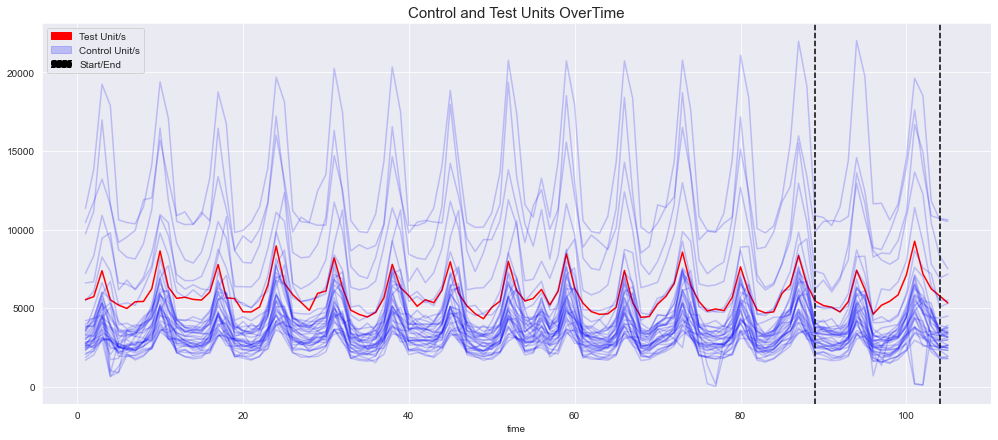

In [52]:
agg_sum_pds.plot()

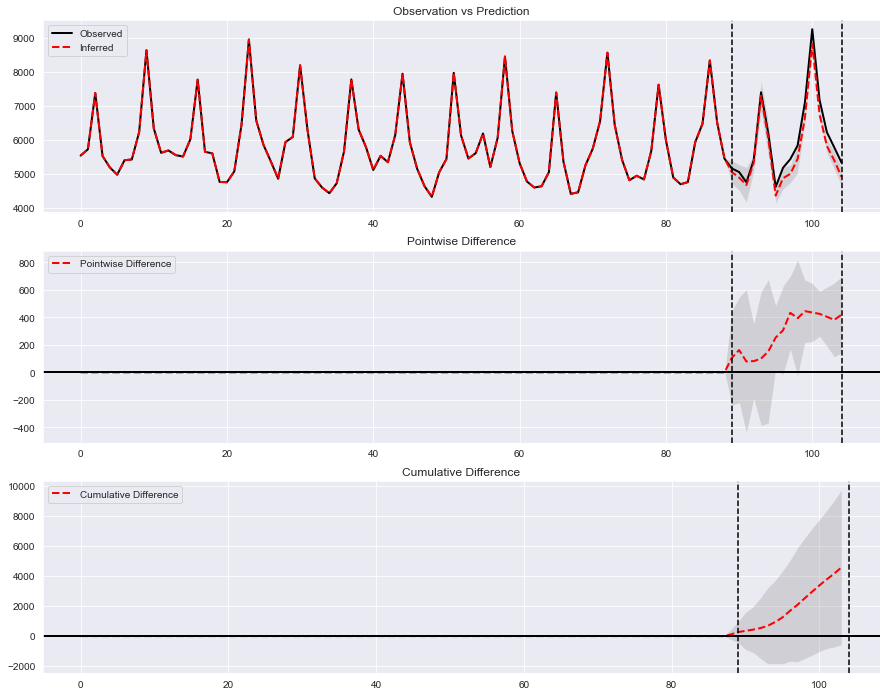

In [63]:
# Variation: 36 Units: 1 Test, Aggregated. No Post-Test-Period

est = TBRRidge(inference='Kfold')
est.run_analysis(agg_sum_pds)
est.plot()

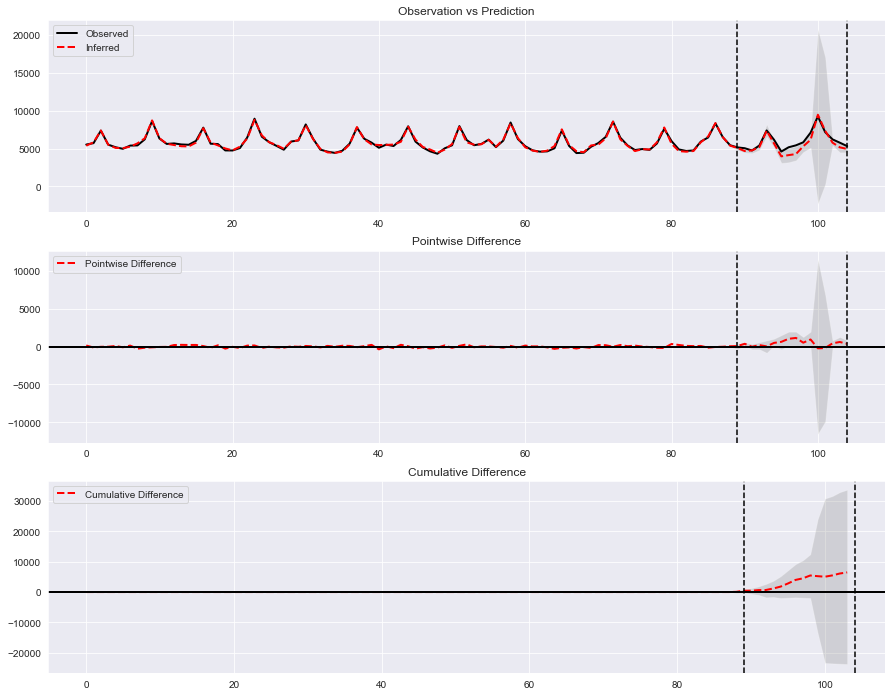

In [64]:
est = TBRRidge(inference='Conformal')
est.run_analysis(agg_sum_pds)
est.plot()

In [65]:
est.summary()

# add more details here 

,Average,Cumulative
Actual,6036.4,90546
Predicted,5628.998351,84434.975262
,,
Absolute Effect,407.401649,6111.024738
,,
Relative Effect,7.237551,7.237551


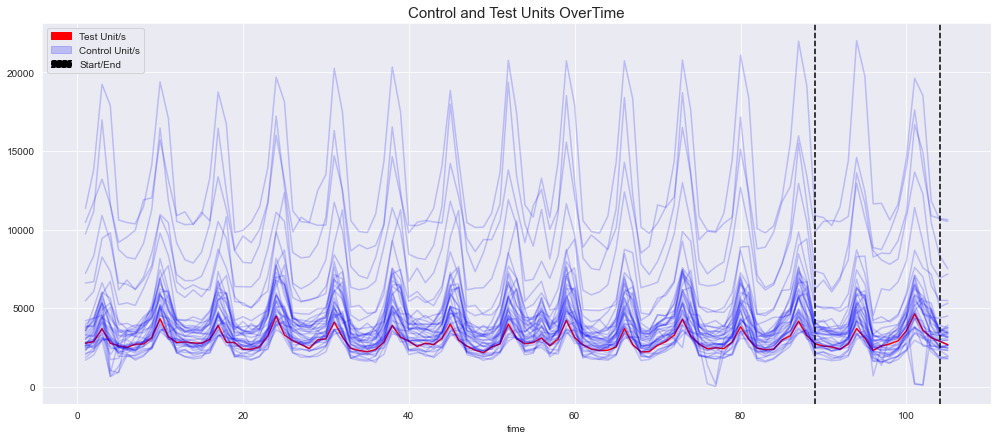

In [66]:
agg_mean_pds.plot()

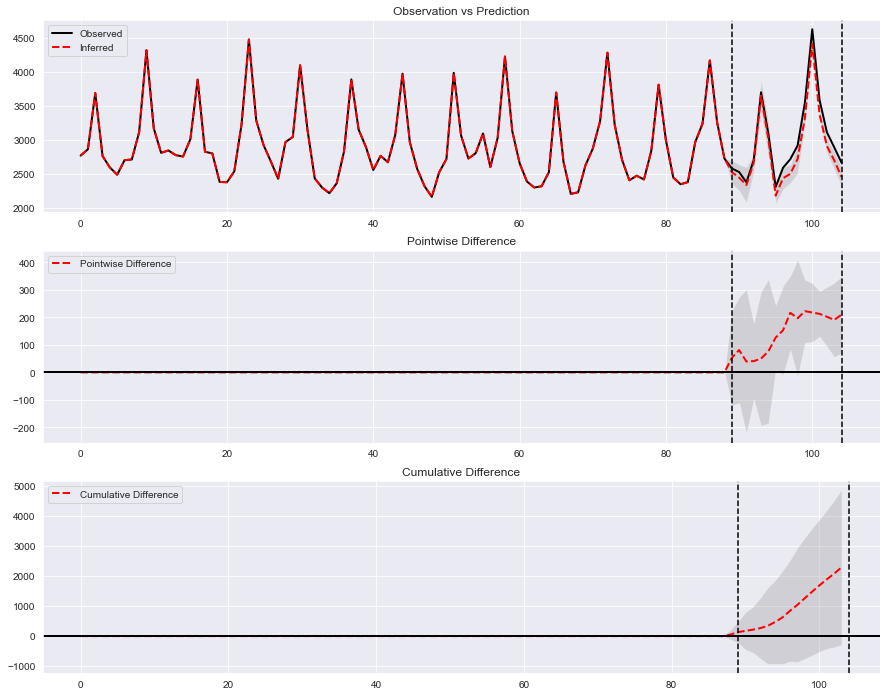

In [67]:
est = TBRRidge(inference='Kfold')
est.run_analysis(agg_mean_pds)
est.plot()

In [68]:
est.summary()

,Average,Cumulative
Actual,3018.2,45273.0
Predicted,2879.34298,43190.144704
,,
Absolute Effect,138.85702,2082.855296
,,
Relative Effect,4.822524,4.822524


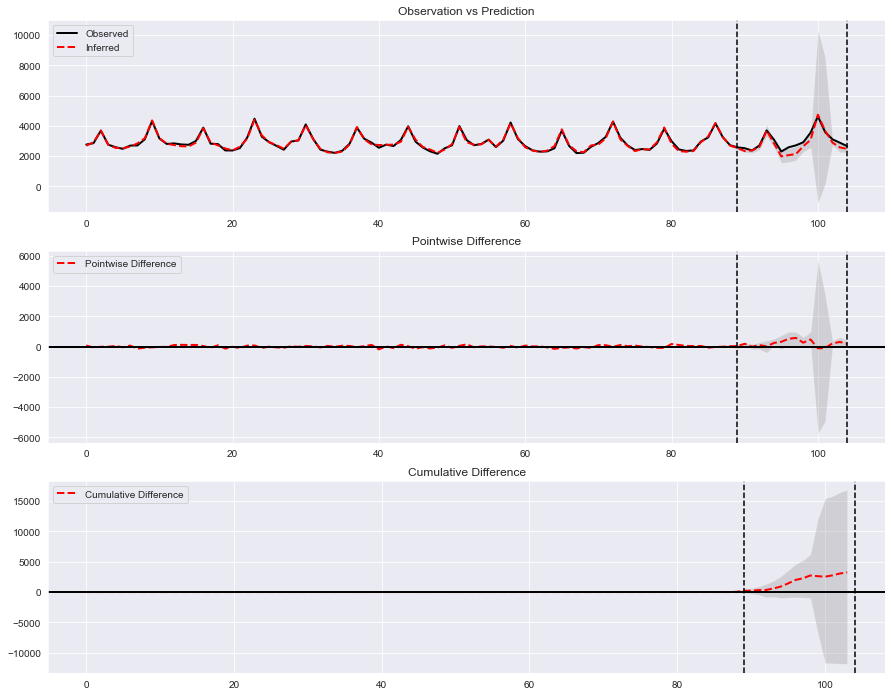

In [69]:
est = TBRRidge(inference='Conformal')
est.run_analysis(agg_mean_pds)
est.plot()

In [70]:
est.summary()

,Average,Cumulative
Actual,3018.2,45273.0
Predicted,2814.499175,42217.487631
,,
Absolute Effect,203.700825,3055.512369
,,
Relative Effect,7.237551,7.237551


In [71]:

    #> One outcome and one treatment time found. Running single_augsynth.
    #>
    #> GeoLift Output
    #>
    #> Test results for 15 treatment periods, from time-stamp 91 to 105 for test markets:
    #> 1 CHICAGO
    #> 2 PORTLAND
    #> ##################################
    #> #####     Test Statistics    #####
    #> ##################################
    #>
    #> Percent Lift: 5.4%
    #>
    #> Incremental Y: 4667
    #>
    #> Average Estimated Treatment Effect (ATT): 155.556
    #>
    #> The results are significant at a 95% level. (TOTAL)


In [76]:
long_df = pd.read_csv('../data/meta_geo.csv')
wide_df = pd.pivot_table(long_df, index='location', columns='time', values='Y')
pds = PanelDataset(wide_df  ) 

control_units = pd.DataFrame(wide_df.loc[[unit for unit in pds.units if unit not in ['chicago', 'portland', 'honolulu']]] ).T
treated_units = pd.DataFrame(wide_df.loc[['chicago', 'portland']] ).T
wide_agg = pd.concat([treated_units, control_units], axis=1)

end = wide_df.columns[-1]
L = len(wide_df.columns)
test_length = 15

test = ['chicago', 'portland']

pds = PanelDataset(wide_agg.T, treated_units = ['chicago', 'portland'], treated_periods=[TimePeriod(start=L-test_length) for _ in range(len(test))])


In [77]:
pds


        Panel Dataset Summary
        ---------------------
        Number of time points: 105
        Number of units: 39
        Number of treated units: 2
        Treated units: ['chicago', 'portland']
        Treated periods: [TimePeriod(start=90, end=None), TimePeriod(start=90, end=None)]
        

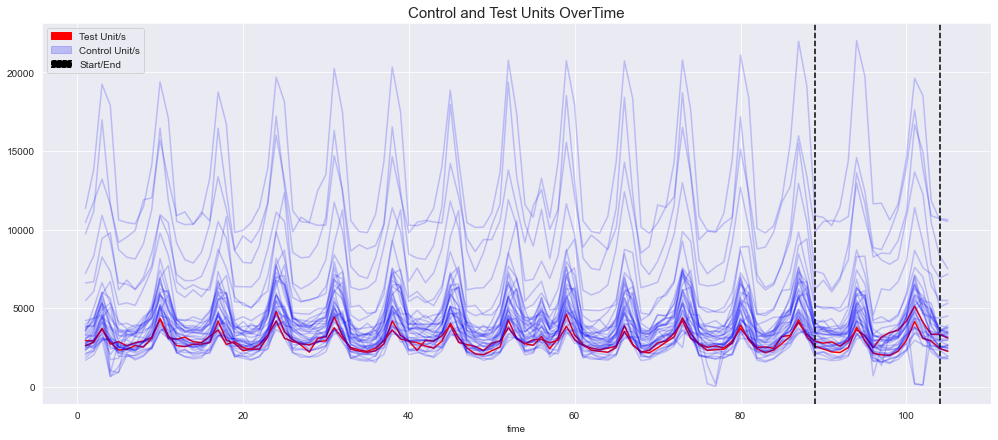

In [78]:
pds.plot()

In [79]:
est = TBRRidge(inference='Kfold')
est.run_analysis(pds)

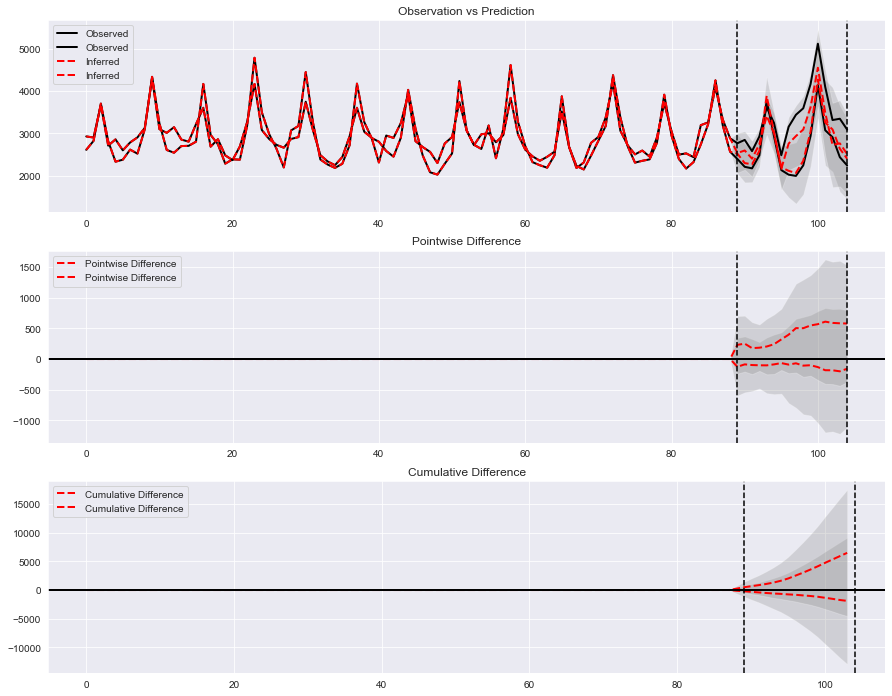

In [80]:
est.plot()

In [81]:
est.summary()

,Average,Cumulative
Actual,3018.2,90546
Predicted,2879.343088,86380.292652
,,
Absolute Effect,138.856912,4165.707348
,,
Relative Effect,4.822521,4.822521


In [43]:
# how is summary computed?
# need p-value
# need confidence intervals 
# 

In [82]:
est = TBRRidge(inference='Conformal')
est.run_analysis(pds)

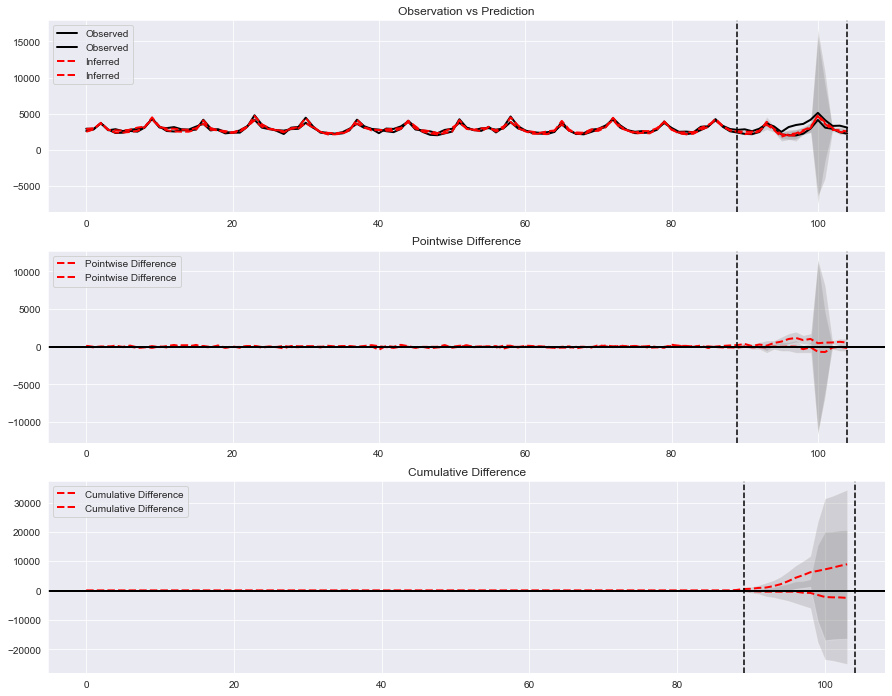

In [83]:
est.plot()

In [84]:
est.summary()

,Average,Cumulative
Actual,3018.2,90546
Predicted,2814.499185,84434.975535
,,
Absolute Effect,203.700815,6111.024465
,,
Relative Effect,7.237551,7.237551


In [85]:
# Testing With SCM

from panel_exp.methods.scm import SyntheticControl 


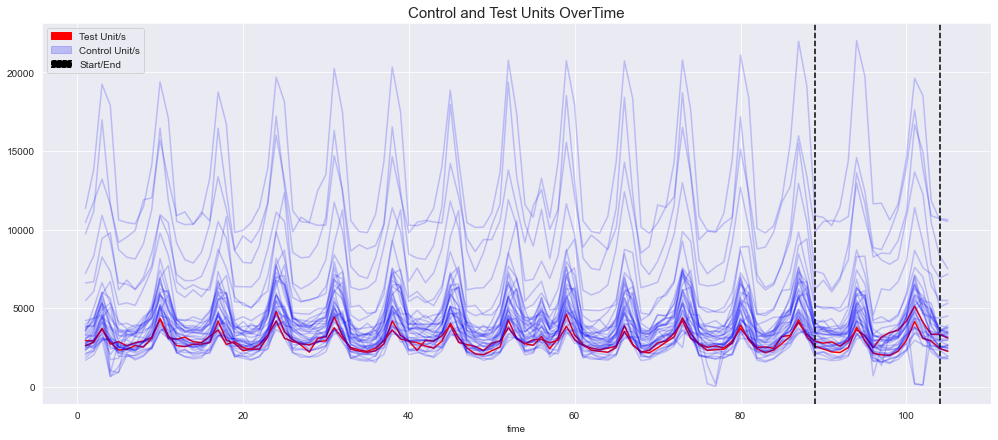

In [86]:
pds.plot()

In [87]:
scm = SyntheticControl(inference='Conformal')


In [89]:
# scm.run_analysis(pds)
# Optimizier Fails 

# Use Google Sales Data

In [91]:
data = pd.read_csv('../../examples/data/google_sales.csv') 

wide_df = pd.pivot_table(data, index='geo', columns='date', values='sales', fill_value=0)

test = data[data.group==2].geo.unique()
control = data[data.group==1].geo.unique()

control_units = pd.DataFrame(wide_df.loc[control]).T
treated_units = pd.DataFrame(wide_df.loc[test].sum(axis=0), columns=['treated'])

wide_agg = pd.concat([treated_units, control_units], axis=1)

test=['treated']

pds = PanelDataset(wide_agg.T
                ,  treated_periods = [TimePeriod(start="2015-02-16", end="2015-03-15") for _ in range(len(test))]
                ,  treated_units = list(test))

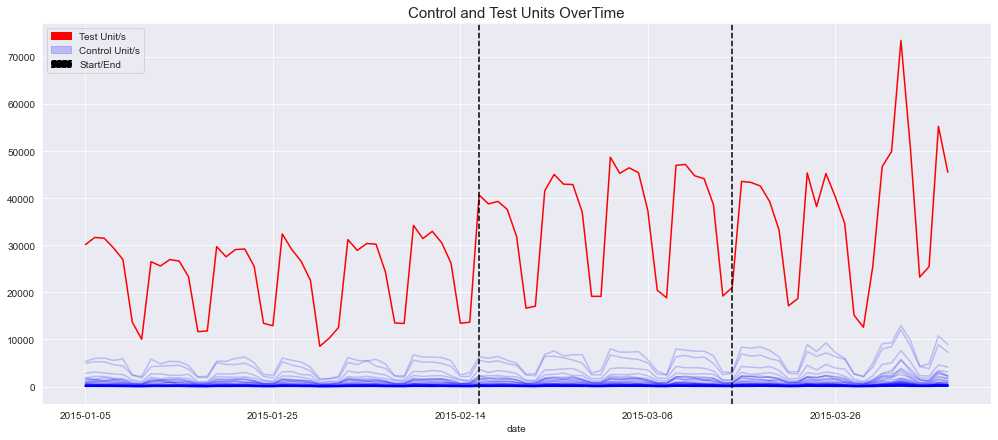

In [93]:
pds.plot()

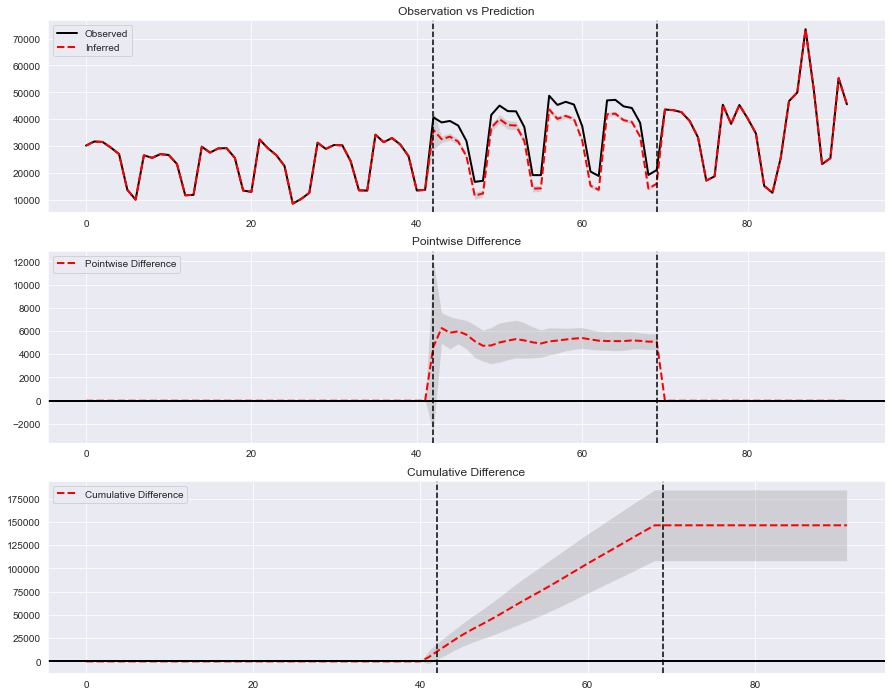

In [94]:
est = TBRRidge( inference='Kfold')
est.run_analysis(pds)

est.plot()

In [95]:
est.summary()

,Average,Cumulative
Actual,36045.661852,973232.87
Predicted,30814.784956,831999.193799
,,
Absolute Effect,5230.876896,141233.676201
,,
Relative Effect,16.975218,16.975218


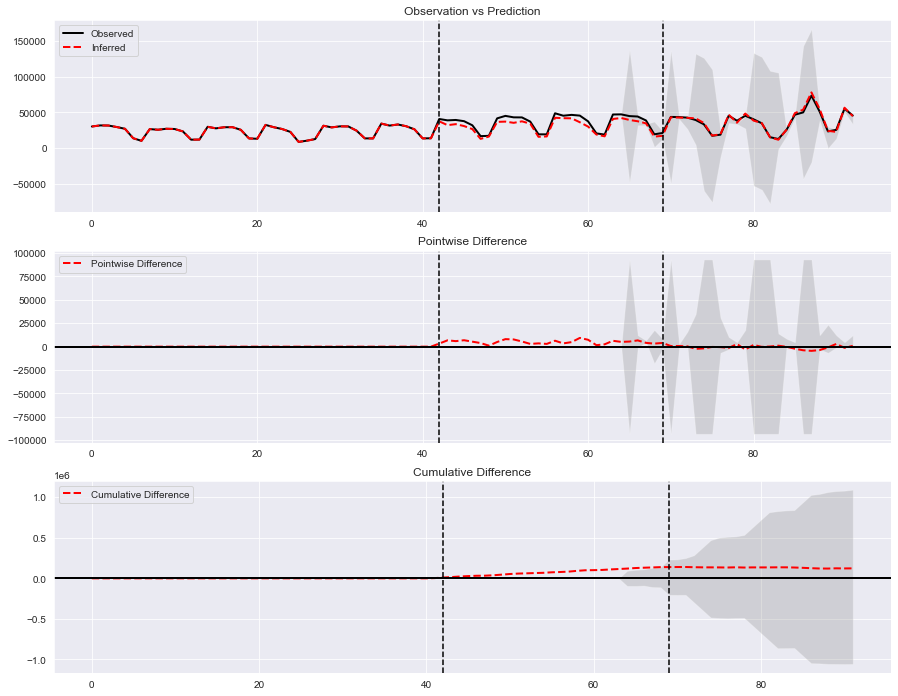

In [96]:
# needs Work 
est = TBRRidge( inference='Conformal')
est.run_analysis(pds)

est.plot()

In [97]:
est.summary()

,Average,Cumulative
Actual,36045.661852,973232.87
Predicted,31064.403374,838738.891088
,,
Absolute Effect,4981.258478,134493.978912
,,
Relative Effect,16.035262,16.035262


In [98]:
data = pd.read_csv('../../examples/data/google_sales.csv') 

wide_df = pd.pivot_table(data, index='geo', columns='date', values='sales', fill_value=0)

test = data[data.group==2].geo.unique()
control = data[data.group==1].geo.unique()

control_units = pd.DataFrame(wide_df.loc[control]).T
treated_units = pd.DataFrame(wide_df.loc[test]).T

wide_agg = pd.concat([treated_units, control_units], axis=1)


pds = PanelDataset(wide_agg.T
                ,  treated_periods = [TimePeriod(start="2015-02-16", end="2015-03-15") for _ in range(len(test))]
                ,  treated_units = list(test))

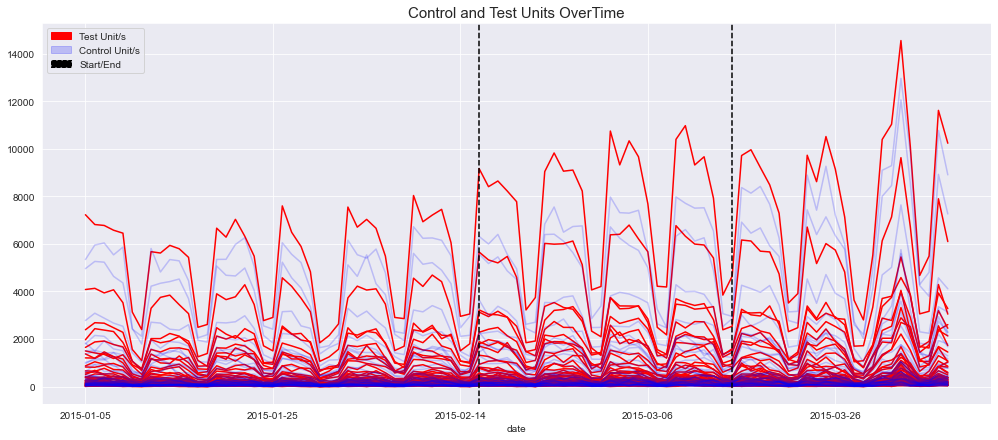

In [99]:
pds.plot()

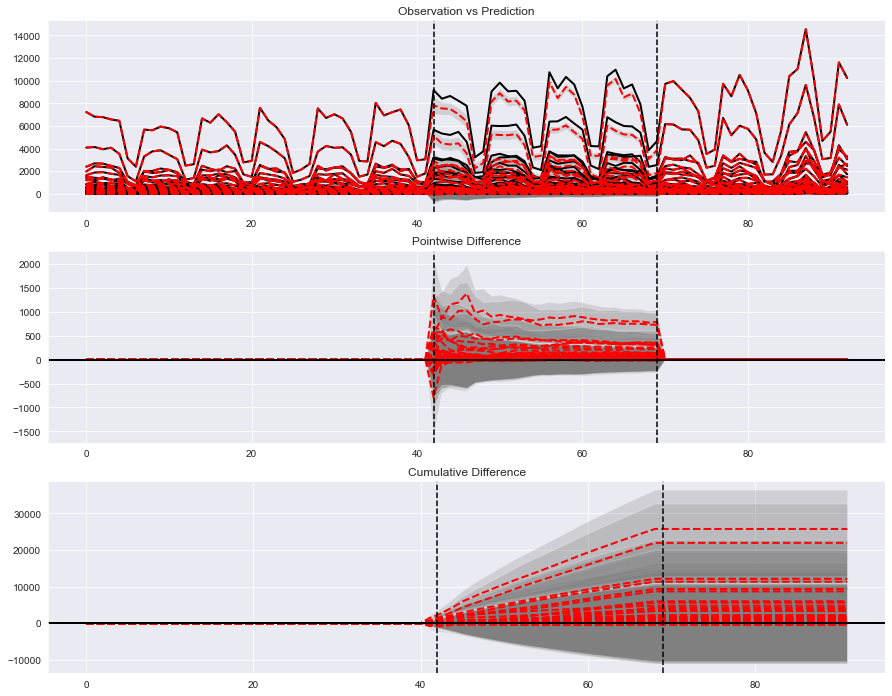

In [101]:
est = TBRRidge( inference='Kfold')
est.run_analysis(pds)

est.plot(legend=False)

In [102]:
est.summary()

,Average,Cumulative
Actual,720.913237,973232.87
Predicted,616.295516,831998.946906
,,
Absolute Effect,104.617721,141233.923094
,,
Relative Effect,16.975253,16.975253


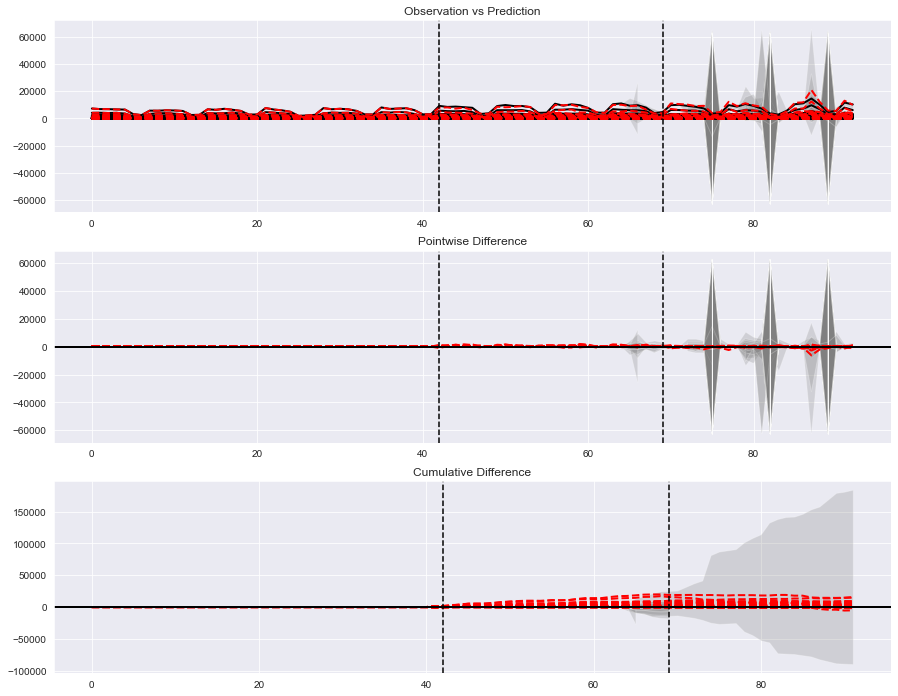

In [103]:
est = TBRRidge( inference='Conformal')
est.run_analysis(pds)

est.plot(legend=False)

In [104]:
est.summary()

,Average,Cumulative
Actual,720.913237,973232.87
Predicted,621.288067,838738.891088
,,
Absolute Effect,99.62517,134493.978912
,,
Relative Effect,16.035262,16.035262


In [105]:
scm = SyntheticControl()

In [106]:
scm.run_analysis(pds)

SolverError: Solver 'OSQP' failed. Try another solver, or solve with verbose=True for more information.

In [107]:
long_df = pd.read_csv('../data/kansas_parsed.csv')


In [113]:
panel_data = long_df_to_paneldataset(long_df, "year_qtr", "state", "lngdp", ["Kansas", "Alaska"], [2012, 2012])


In [114]:
scm = SyntheticControl(inference='Conformal')


In [116]:
scm.run_analysis(panel_data)

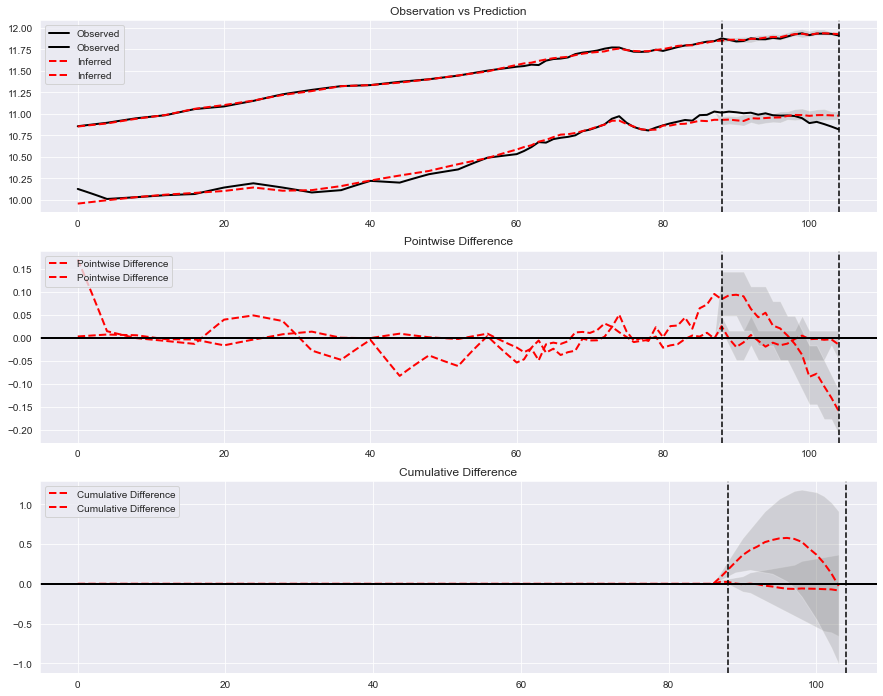

In [117]:
scm.plot()

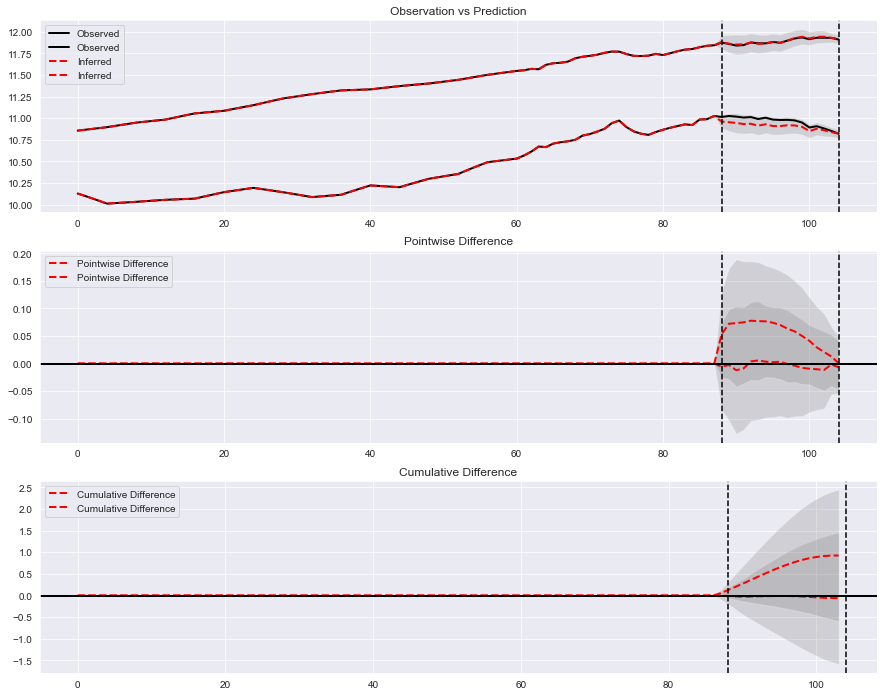

In [118]:
scm = SyntheticControl(inference='Kfold')
scm.run_analysis(panel_data)
scm.plot()

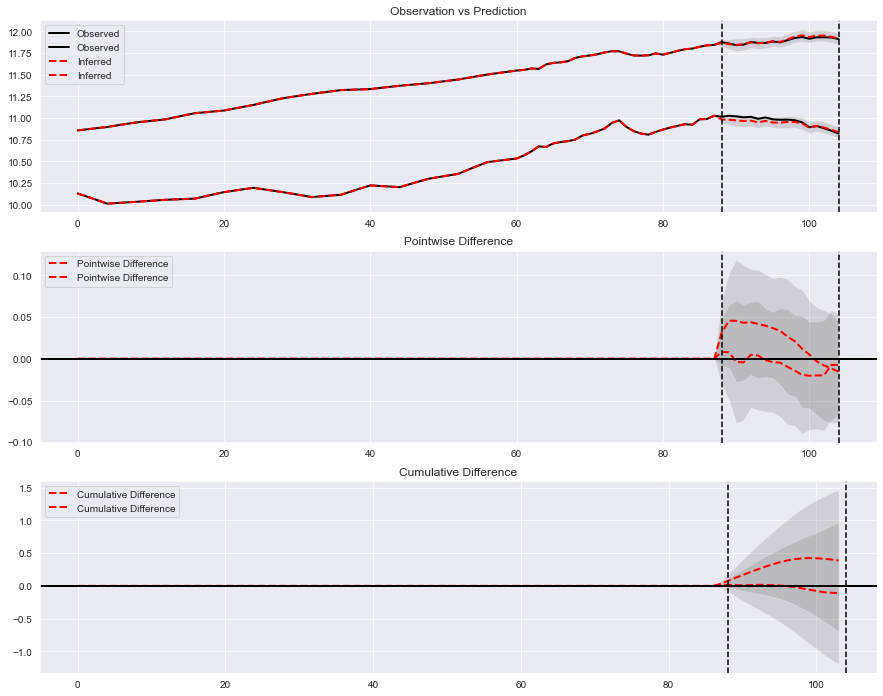

In [119]:


scm = AugSynth(inference='Kfold')
scm.run_analysis(panel_data)
scm.plot()

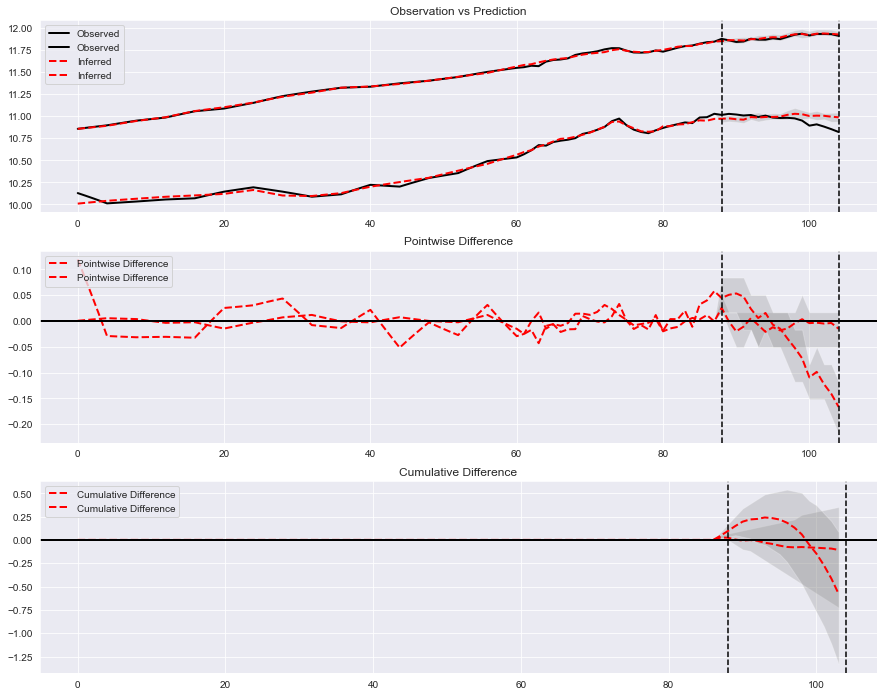

In [120]:
scm = AugSynth(inference='Conformal')
scm.run_analysis(panel_data)
scm.plot()